# 취준생 AI 면접 코칭 전·후 효과성 검정

## 분석 목적
취업준비생 25명을 대상으로 AI 면접 코칭을 실시한 뒤,  
교육 전과 교육 후의 모의면접 점수에 유의미한 차이가 있는지 확인한다.  
어떤 검정 방법을 사용하면 좋을지 판단하고 가설검정을 수행하세요.  
    - 쌍체 표본 t-검정

## 1. 가설 설정

### 귀무가설(H₀)
AI 면접 코칭 전과 후의 평균 모의면접 점수는 같다(차이가 없다).

### 대립가설(H₁)
AI 면접 코칭 전과 후의 평균 모의면접 점수에는 다르다(차이가 있다).

유의수준은 **α = 0.05**로 설정한다.

- p-value < 0.05 → 귀무가설 기각
- p-value ≥ 0.05 → 귀무가설을 기각하지 못함


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 데이터 불러오기
df = pd.read_csv("jobseekers_25.csv")

df.head()


,before_score,after_score
0,62,66
1,68,71
2,71,76
3,65,67
4,74,78


In [10]:
# A그룹
before = df['before_score']
# B그룹
after = df['after_score']

In [11]:
# 정규성 검정
from scipy import stats

stats.shapiro(after - before)

ShapiroResult(statistic=np.float64(0.9632940103365952), pvalue=np.float64(0.4839002174433268))

[해석]

p-value > 0.05 이므로, 정규분포를 따른다는 것을 알 수 있음

In [12]:
# 쌍체 표본 t 검정
stats.ttest_rel(before, after)

TtestResult(statistic=np.float64(-13.587324409735148), pvalue=np.float64(9.163952098716969e-13), df=np.int64(24))

[해석]

- p-value <= 0.05 : 귀무가설을 기각함.
    - 두 집단 간의 평균 차이가 통계적으로 유의하다고 할 수 있음.
    - 확실하게 AI 면접 코칭 효과가 있음을 확인
- h0 : d = 0, h1 : d != 0
- 통계량이 음수 이기 때문에 음의 효과 있다는 것을 알 수 있음

In [13]:
import numpy as np
np.mean(before), np.mean(after)

(np.float64(68.76), np.float64(72.76))

In [14]:
np.mean(before) - np.mean(after)

np.float64(-4.0)

In [15]:
# 전후 차이 계산
diff = before - after

# 모의 면접 점수 차이의 평균 계산
mean_diff = np.mean(diff)

# 모의 면접 점수 차이의 표준편차
std_diff = np.std(diff, ddof=1)

# 모의 면접 점수 차이의 표준오차(표본에서 구한 모의 면접 점수 변화량의 불확실성을 나타냄)
standard_error = std_diff / np.sqrt(len(diff))

# t-통계량 계산
t_statistic = mean_diff / standard_error
t_statistic

np.float64(-13.587324409735151)

In [17]:
# 계산 결과 출력
print(mean_diff)      
print(std_diff)       
print(standard_error)
print(t_statistic)     # t 통계량

-4.0
1.4719601443879744
0.29439202887759486
-13.587324409735151


## 2. 데이터 구조 확인

- `before_score` : AI 면접 코칭 전 점수
- `after_score` : AI 면접 코칭 후 점수


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   before_score  25 non-null     int64
 1   after_score   25 non-null     int64
dtypes: int64(2)
memory usage: 532.0 bytes


In [4]:
df.describe()


,before_score,after_score
count,25.000000,25.000000
mean,68.760000,72.760000
std,4.557777,4.926797
min,61.000000,66.000000
25%,65.000000,68.000000
50%,69.000000,72.000000
75%,72.000000,76.000000
max,77.000000,82.000000


## 3. 교육 전·후 평균 비교

단순히 평균을 먼저 비교하여 교육 전과 후의 점수가 어떤 방향으로 변했는지 확인한다.


In [5]:
before_mean = df["before_score"].mean()
after_mean = df["after_score"].mean()

print(f"교육 전 평균: {before_mean:.2f}")
print(f"교육 후 평균: {after_mean:.2f}")
print(f"평균 변화량: {after_mean - before_mean:.2f}")


교육 전 평균: 68.76
교육 후 평균: 72.76
평균 변화량: 4.00


## 4. 개인별 점수 변화 확인


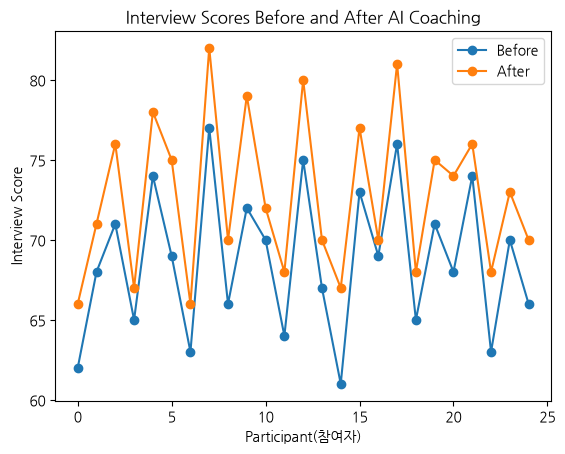

In [6]:
# plt.rcParams["font.family"] = 'Malgun Gothic'  # 윈도우
plt.rcParams['font.family'] = 'NanumGothic'      # 우분투
plt.rcParams['axes.unicode_minus'] = False
plt.plot(df["before_score"], marker="o", label="Before")
plt.plot(df["after_score"], marker="o", label="After")
plt.xlabel("Participant(참여자)")
plt.ylabel("Interview Score")
plt.title("Interview Scores Before and After AI Coaching")
plt.legend()
plt.show()
